In [1]:
import pandas as pd
import numpy as np

# Random Forrest and Multi-Layer Perceptron Analysis

## Data preparation and varialble selection

An analysis through RF and MLP. The data was read, cleaned, and categorical variables were one-hot encoded. Date variables about the listing (`date_crawle`, `last_seen` and `ad_created`) were removed because all observations belong to a short time window. The variables `model` and `postal_code` were also removed. There were more than 200 unique models, and the complete postal code provided very little information. Instead, a `region` variable was creatied, containing the general region of the listing (first digit of the postal code). The `car_name` was also removed.

An `age`variable was created to replace `registration_year`. The `registration_month` was removed.

$ age = 2016 - registration\_year $


Before removal of `model` and `postal_code`, a correlations analysis was performed to observe the relationship of each individual variable to the target `price_EUR` variable. The only model showing a significant correlation with price was `model_911`, with a correlation of `0.344658`. Therfore, the removal of these variables is justified: they are too much data that provides very little information.

Categorical variables were one-hot encoded and missing values were treater as their own category.

In [ ]:
filepath = "autos_random_50k_cleaned.csv"

autos = pd.read_csv(filepath, encoding="Latin-1")
autos = autos.drop(columns=["date_crawled", "Unnamed: 0", "last_seen", "car_name", "ad_created"])

autos['unrepaired_damage'] = autos['unrepaired_damage'].map({'nein': False, 'ja': True, 'Unknown': pd.NA})
autos['is_automatic'] = autos['transmission'].map({'manuell': False, 'automatik': True, 'Unknown': pd.NA})
autos.drop(columns=['transmission'], inplace=True)
autos['is_test'] = autos['ab_test'].map({'control': False, 'test': True})
autos.drop(columns=['ab_test'], inplace=True)
autos['region'] = autos['postal_code'].apply(lambda x: str(x)[:1])
autos['zone'] = autos['postal_code'].apply(lambda x: str(x)[:2])
autos.drop(columns=['postal_code'], inplace=True)
autos['fuel_type'] = autos['fuel_type'].replace('Unknown', pd.NA)
autos['vehicle_type'] = autos['vehicle_type'].replace('Unknown', pd.NA)
autos['model'] = autos['model'].replace('Unknown', pd.NA)


autos.head()

,price_EUR,vehicle_type,registration_year,power_ps,model,odometer_km,registration_month,fuel_type,brand,unrepaired_damage,is_automatic,is_test,region,zone
0,5200,cabrio,2002,235,astra,125000,5,<NA>,opel,False,False,True,4,47
1,3400,kleinwagen,2006,65,andere,125000,5,benzin,fiat,False,False,True,6,66
2,5200,suv,2009,220,xc_reihe,150000,3,diesel,volvo,True,True,True,7,72
3,750,kombi,2000,112,mondeo,150000,12,benzin,ford,<NA>,False,True,3,39
4,3522,limousine,2004,131,a4,150000,7,diesel,audi,False,False,True,5,51


In [4]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37866 entries, 0 to 37865
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   price_EUR           37866 non-null  int64 
 1   vehicle_type        37047 non-null  object
 2   registration_year   37866 non-null  int64 
 3   power_ps            37866 non-null  int64 
 4   model               36677 non-null  object
 5   odometer_km         37866 non-null  int64 
 6   registration_month  37866 non-null  int64 
 7   fuel_type           36581 non-null  object
 8   brand               37866 non-null  object
 9   unrepaired_damage   33770 non-null  object
 10  is_automatic        37400 non-null  object
 11  is_test             37866 non-null  bool  
 12  region              37866 non-null  object
 13  zone                37866 non-null  object
dtypes: bool(1), int64(5), object(8)
memory usage: 3.8+ MB


In [59]:
s = pd.get_dummies(autos).corr()['price_EUR'].sort_values(ascending=False)
# show a preview in the notebook
print(s.head(20).to_string())

# write full output to a text file
out_path = "price_EUR_correlations.txt"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(s.to_string())

print(f"\nFull correlation series written to {out_path}")

price_EUR                  1.000000
power_ps                   0.467123
model_911                  0.344658
brand_porsche              0.314096
registration_year          0.267753
is_automatic_True          0.212990
vehicle_type_coupe         0.138174
fuel_type_diesel           0.129370
vehicle_type_suv           0.128749
unrepaired_damage_False    0.126887
vehicle_type_cabrio        0.114261
brand_sonstige_autos       0.098688
model_x_reihe              0.083729
brand_audi                 0.079222
model_a5                   0.073453
model_q5                   0.070448
model_m_reihe              0.070029
model_sl                   0.068393
brand_bmw                  0.066149
brand_mercedes_benz        0.064654

Full correlation series written to price_EUR_correlations.txt


In [5]:
for col in autos.select_dtypes(include=['object']).columns:
    print(f"{col}:\n{autos[col].value_counts()}\n")
    print(f"count: {autos[col].count()}\n")
    print("-----\n")

vehicle_type:
vehicle_type
limousine     11046
kleinwagen     7977
kombi          7615
bus            3499
cabrio         2711
coupe          2140
suv            1762
andere          297
Name: count, dtype: int64

count: 37047

-----

model:
model
golf       3117
andere     2718
3er        2260
polo       1172
a4         1153
           ... 
lodgy         2
i3            1
move          1
kappa         1
materia       1
Name: count, Length: 243, dtype: int64

count: 36677

-----

fuel_type:
fuel_type
benzin     23456
diesel     12417
lpg          603
cng           53
hybrid        35
andere        14
elektro        3
Name: count, dtype: int64

count: 36581

-----

brand:
brand
volkswagen        8066
bmw               4528
mercedes_benz     3935
opel              3601
audi              3589
ford              2360
renault           1531
peugeot           1134
fiat               836
seat               712
skoda              689
mazda              610
smart              572
toyota         

In [ ]:
autos_encoded = autos.drop(columns=['model', 'zone'])
autos_encoded['fuel_type'] = autos_encoded['fuel_type'].mask(
    autos_encoded['fuel_type'].notna() & ~autos_encoded['fuel_type'].isin(['benzin', 'diesel']),
    pd.NA
)
autos_encoded['vehicle_type'] = autos_encoded['vehicle_type'].replace('andere', pd.NA)
autos_encoded['age'] = 2016 - autos_encoded['registration_year']
autos_encoded.drop(columns=['registration_year'], inplace=True)
autos_encoded.drop(columns=['registration_month'], inplace=True)

In [73]:
autos_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37866 entries, 0 to 37865
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   price_EUR          37866 non-null  int64 
 1   vehicle_type       36750 non-null  object
 2   power_ps           37866 non-null  int64 
 3   model              36677 non-null  object
 4   odometer_km        37866 non-null  int64 
 5   fuel_type          35873 non-null  object
 6   brand              37866 non-null  object
 7   unrepaired_damage  33770 non-null  object
 8   is_automatic       37400 non-null  object
 9   is_test            37866 non-null  bool  
 10  region             37866 non-null  object
 11  zone               37866 non-null  object
 12  age                37866 non-null  int64 
dtypes: bool(1), int64(4), object(8)
memory usage: 3.5+ MB


In [74]:
# count missing values per column
missing_values = autos_encoded.isnull().sum()
print("Missing values per column:\n", missing_values)

# count total rows with missing values
total_missing_rows = autos_encoded.isnull().any(axis=1).sum()
print("Total rows with missing values:", total_missing_rows)

Missing values per column:
 price_EUR               0
vehicle_type         1116
power_ps                0
model                1189
odometer_km             0
fuel_type            1993
brand                   0
unrepaired_damage    4096
is_automatic          466
is_test                 0
region                  0
zone                    0
age                     0
dtype: int64
Total rows with missing values: 6958


In [86]:
for col in ['is_automatic', 'unrepaired_damage', 'vehicle_type', 'fuel_type']:
    autos_encoded[col] = (
        autos_encoded[col]
        .astype(str) # Converts True/False/pd.NA to 'True'/'False'/'NA'
        .replace('<NA>', 'Missing') # Replace the string representation of pd.NA
    )

In [20]:
for col in autos_encoded.select_dtypes(include=['object']).columns:
    print(f"{col}:\n{autos_encoded[col].value_counts()}\n")
    print(f"count: {autos_encoded[col].count()}\n")
    print("-----\n")

vehicle_type:
vehicle_type
limousine     11046
kleinwagen     7977
kombi          7615
bus            3499
cabrio         2711
coupe          2140
suv            1762
Name: count, dtype: int64

count: 36750

-----

brand:
brand
volkswagen        8066
bmw               4528
mercedes_benz     3935
opel              3601
audi              3589
ford              2360
renault           1531
peugeot           1134
fiat               836
seat               712
skoda              689
mazda              610
smart              572
toyota             551
citroen            534
nissan             498
mini               430
hyundai            393
volvo              377
sonstige_autos     300
mitsubishi         299
honda              288
kia                276
porsche            263
alfa_romeo         244
suzuki             230
chevrolet          176
chrysler           150
dacia              105
land_rover          82
jeep                79
subaru              74
jaguar              69
daihatsu     

In [87]:
autos_encoded = pd.get_dummies(autos_encoded, drop_first=True)

In [88]:
autos_encoded.head()

,price_EUR,power_ps,odometer_km,is_test,age,vehicle_type_bus,vehicle_type_cabrio,vehicle_type_coupe,vehicle_type_kleinwagen,vehicle_type_kombi,...,is_automatic_Missing,is_automatic_True,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9
0,5200,235,125000,True,14,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,3400,65,125000,True,10,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
2,5200,220,150000,True,7,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
3,750,112,150000,True,16,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
4,3522,131,150000,True,12,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [55]:
# correlation matrix
correlation_matrix = autos_encoded.corr()
print(correlation_matrix['price_EUR'].sort_values(ascending=False))

price_EUR                  1.000000
power_ps                   0.467123
brand_porsche              0.314096
is_automatic_True          0.212990
vehicle_type_coupe         0.138174
                             ...   
unrepaired_damage_True    -0.092269
fuel_type_benzin          -0.106366
vehicle_type_kleinwagen   -0.157882
age                       -0.267753
odometer_km               -0.347364
Name: price_EUR, Length: 65, dtype: float64


## Random Forrest Regression

Variance of test data explained: 0.804

Mean Absolute Error: 1615.6178084137173
Feature Importances:
power_ps                3.442258e-01
age                     2.399260e-01
odometer_km             1.716920e-01
brand_porsche_True      2.647668e-02
brand_porsche_False     2.588995e-02
                            ...     
brand_daihatsu_False    2.571724e-06
brand_rover_True        1.200571e-06
brand_rover_False       1.135241e-06
brand_daewoo_True       1.024524e-06
brand_daewoo_False      9.532390e-07
Length: 125, dtype: float64


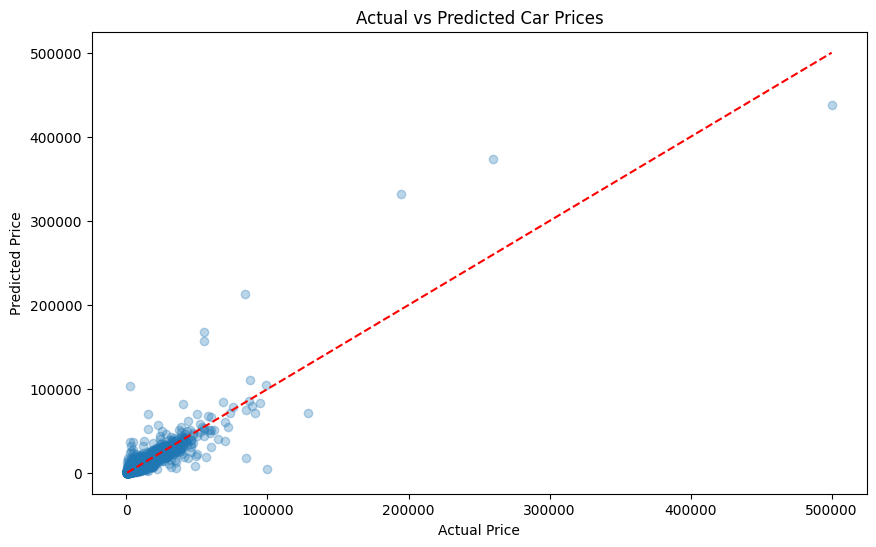

In [ ]:
# Random forrest regressor to predict price
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Prepare data for modeling
autos_model = autos_encoded.dropna()
X = autos_model.drop(columns=['price_EUR'])
y = autos_model['price_EUR']   
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns
numerical_cols = X.select_dtypes(include=['number']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])
X_preprocessed = preprocessor.fit_transform(X)
X_train, X_valid, y_train, y_valid = train_test_split(X_preprocessed, y, train_size=0.8, random_state=42)
rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_valid)
mae = mean_absolute_error(y_valid, y_pred_rf)
print(f"Mean Absolute Error: {mae}")

# Feature importance
importances = rf_model.feature_importances_
feature_names = numerical_cols.tolist() + preprocessor.named_transformers_['cat'].get_feature_names_out().tolist()
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("Feature Importances:")
print(feature_importances)  

# Graph actual vs predicted prices
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_valid, y_pred_rf, alpha=0.3)
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()

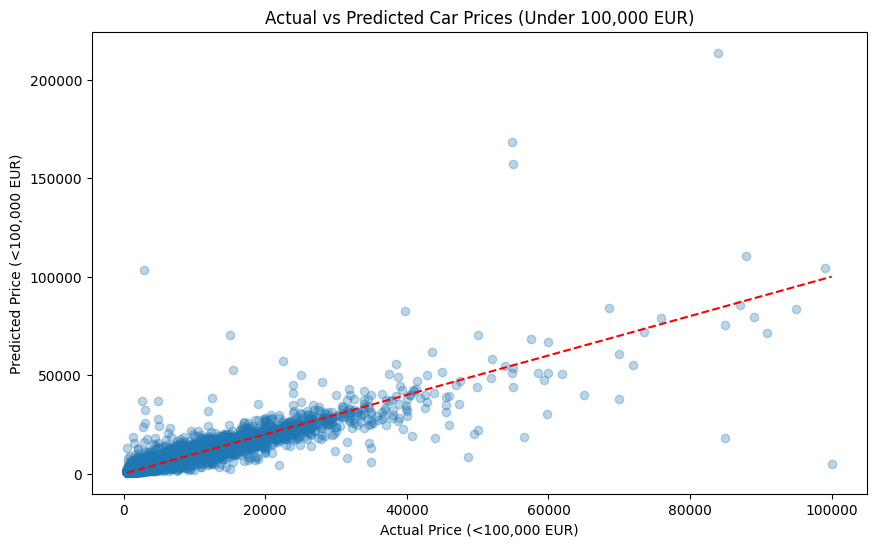

In [ ]:
# Only plot for prices under 100,000 EUR

mask = y_valid < 100000
plt.figure(figsize=(10, 6))
plt.scatter(y_valid[mask], y_pred_rf[mask], alpha=0.3)
plt.plot([y_valid[mask].min(), y_valid[mask].max()], [y_valid[mask].min(), y_valid[mask].max()], 'r--')
plt.xlabel('Actual Price (<100,000 EUR)')
plt.ylabel('Predicted Price (<100,000 EUR)')
plt.title('Actual vs Predicted Car Prices (Under 100,000 EUR)')
plt.show()

In [112]:
y_pred_rf = model.predict(X_valid)
mae = mean_absolute_error(y_valid, y_pred_rf)
# R squared
from sklearn.metrics import r2_score
r2 = r2_score(y_valid, y_pred_rf)
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

Mean Absolute Error: 1615.6178084137173
R^2 Score: 0.8039996631923312


In [89]:
# pca of autos_encoded dataframe, print variance explained
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(autos_encoded.drop(columns=['price_EUR']).dropna())
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print("Cumulative explained variance by principal components:")
for i, var in enumerate(cumulative_variance):
    print(f"{i+1}: PC1 to PC{i+1}: {var:.4f}")

Cumulative explained variance by principal components:
1: PC1 to PC1: 0.0444
2: PC1 to PC2: 0.0771
3: PC1 to PC3: 0.1041
4: PC1 to PC4: 0.1266
5: PC1 to PC5: 0.1482
6: PC1 to PC6: 0.1690
7: PC1 to PC7: 0.1890
8: PC1 to PC8: 0.2085
9: PC1 to PC9: 0.2272
10: PC1 to PC10: 0.2458
11: PC1 to PC11: 0.2642
12: PC1 to PC12: 0.2821
13: PC1 to PC13: 0.2999
14: PC1 to PC14: 0.3176
15: PC1 to PC15: 0.3351
16: PC1 to PC16: 0.3526
17: PC1 to PC17: 0.3695
18: PC1 to PC18: 0.3865
19: PC1 to PC19: 0.4033
20: PC1 to PC20: 0.4199
21: PC1 to PC21: 0.4365
22: PC1 to PC22: 0.4528
23: PC1 to PC23: 0.4689
24: PC1 to PC24: 0.4850
25: PC1 to PC25: 0.5010
26: PC1 to PC26: 0.5170
27: PC1 to PC27: 0.5329
28: PC1 to PC28: 0.5487
29: PC1 to PC29: 0.5645
30: PC1 to PC30: 0.5803
31: PC1 to PC31: 0.5961
32: PC1 to PC32: 0.6118
33: PC1 to PC33: 0.6276
34: PC1 to PC34: 0.6433
35: PC1 to PC35: 0.6590
36: PC1 to PC36: 0.6747
37: PC1 to PC37: 0.6904
38: PC1 to PC38: 0.7061
39: PC1 to PC39: 0.7217
40: PC1 to PC40: 0.7374
41:

## MLP

Multiple attempts at different configurations of MLP. The best result came from two hidden layers of 144 and 16 neurons each. This configuration barely managed to outperform the Random Forrest Regressor. However, the mean abloslute error is slightly larger.

ReLU activation layers.

Adam gradient solver.

Proportion of variance explained: 0.8158.

In [ ]:
from sklearn.neural_network import MLPRegressor 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score 

autos_model = autos_encoded.dropna()
X = autos_model.drop(columns=['price_EUR'])
y = autos_model['price_EUR']   
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(144, 16), 
    max_iter=750, 
    activation='relu',
    solver='adam',
    random_state=1,
    verbose=False,
    tol=1e-4
)

print("Training the MLP Regressor...")
mlp.fit(X_train_scaled, y_train)

y_pred_rf = mlp.predict(X_test_scaled)

print("\n--- Evaluation on Test Set (Regression Metrics) ---")

mae = mean_absolute_error(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")

r2 = r2_score(y_test, y_pred_rf)
print(f"R-squared (R²): {r2:.4f}")

Training the MLP Regressor...

--- Evaluation on Test Set (Regression Metrics) ---
Mean Absolute Error (MAE): 1861.60 EUR
R-squared (R²): 0.8158


/usr/local/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (750) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPRegressor(
    hidden_layer_sizes=(144, 16, 8), 
    max_iter=1500, 
    alpha=0.001,
    activation='relu',
    early_stopping=True,
    n_iter_no_change=20,
    solver='adam',
    random_state=1,
    verbose=False,
    tol=1e-4
)

print("Training the MLP Regressor...")
mlp.fit(X_train_scaled, y_train)

y_pred_rf = mlp.predict(X_test_scaled)

print("\n--- Evaluation on Test Set (Regression Metrics) ---")

mae = mean_absolute_error(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")

r2 = r2_score(y_test, y_pred_rf)
print(f"R-squared (R²): {r2:.4f}")

Training the MLP Regressor...

--- Evaluation on Test Set (Regression Metrics) ---
Mean Absolute Error (MAE): 1932.97 EUR
R-squared (R²): 0.6664


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(256, 32, 12), 
    max_iter=2500, 
    alpha=0.001,
    activation='relu',
    early_stopping=True,
    n_iter_no_change=20,
    solver='adam',
    random_state=1,
    verbose=False,
    tol=1e-4
)

print("Training the MLP Regressor...")
mlp.fit(X_train_scaled, y_train)

y_pred_rf = mlp.predict(X_test_scaled)

print("\n--- Evaluation on Test Set (Regression Metrics) ---")

mae = mean_absolute_error(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")

r2 = r2_score(y_test, y_pred_rf)
print(f"R-squared (R²): {r2:.4f}")

Training the MLP Regressor...

--- Evaluation on Test Set (Regression Metrics) ---
Mean Absolute Error (MAE): 1899.80 EUR
R-squared (R²): 0.6510


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(256, 32, 12),
    max_iter=2000, 
    alpha=0.01, 
    early_stopping=True, 
    n_iter_no_change=20, 
    validation_fraction=0.1, 
    random_state=1,
    solver='adam',
    activation='relu',
    verbose=True 
)

print("Training the MLP Regressor (Verbose Output Enabled)...")
mlp.fit(X_train_scaled, y_train)

y_pred_rf = mlp.predict(X_test_scaled)

print("\n--- Evaluation on Test Set ---")
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")
print(f"R-squared (R²): {r2:.4f}")

print("\n--- Detailed Training Diagnostics ---")

print(f"Total Iterations Run: {mlp.n_iter_}")

print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")

if mlp.n_iter_ < mlp.max_iter:
    print(f"Stopping Reason: Early stopping was triggered (Validation score did not improve for {mlp.n_iter_no_change} consecutive epochs).")
else:
    print(f"Stopping Reason: Model reached maximum iterations ({mlp.max_iter}).")

if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")

print("\nLast 10 Training Loss Values:")
print(mlp.loss_curve_[-10:])

Training the MLP Regressor (Verbose Output Enabled)...
Iteration 1, loss = 95295821.83185598
Validation score: -0.361095
Iteration 2, loss = 67097323.06388821
Validation score: 0.501918
Iteration 3, loss = 48339682.88179257
Validation score: 0.591080
Iteration 4, loss = 44945489.78003863
Validation score: 0.615524
Iteration 5, loss = 43363901.95584077
Validation score: 0.626693
Iteration 6, loss = 42673442.84641469
Validation score: 0.629224
Iteration 7, loss = 42012259.67467491
Validation score: 0.633851
Iteration 8, loss = 41550435.05431700
Validation score: 0.637225
Iteration 9, loss = 41316902.39516559
Validation score: 0.637575
Iteration 10, loss = 40955024.58672862
Validation score: 0.639166
Iteration 11, loss = 40602160.26738591
Validation score: 0.645726
Iteration 12, loss = 40436016.51274794
Validation score: 0.646077
Iteration 13, loss = 40169907.29148579
Validation score: 0.642050
Iteration 14, loss = 40021114.11401913
Validation score: 0.648556
Iteration 15, loss = 39730836

In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 16),
    max_iter=2000, 
    alpha=0.01, 
    early_stopping=True, 
    n_iter_no_change=20, 
    validation_fraction=0.1, 
    random_state=1,
    solver='adam',
    activation='relu',
    verbose=True 
)

print("Training the MLP Regressor (Verbose Output Enabled)...")
mlp.fit(X_train_scaled, y_train)

y_pred_rf = mlp.predict(X_test_scaled)

print("\n--- Evaluation on Test Set ---")
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")
print(f"R-squared (R²): {r2:.4f}")

print("\n--- Detailed Training Diagnostics ---")

print(f"Total Iterations Run: {mlp.n_iter_}")

print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")

if mlp.n_iter_ < mlp.max_iter:
    print(f"Stopping Reason: Early stopping was triggered (Validation score did not improve for {mlp.n_iter_no_change} consecutive epochs).")
else:
    print(f"Stopping Reason: Model reached maximum iterations ({mlp.max_iter}).")

if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")

print("\nLast 10 Training Loss Values:")
print(mlp.loss_curve_[-10:])

Training the MLP Regressor (Verbose Output Enabled)...
Iteration 1, loss = 96199751.68186183
Validation score: -0.517030
Iteration 2, loss = 93645912.29891650
Validation score: -0.400034
Iteration 3, loss = 84817639.85542767
Validation score: -0.126461
Iteration 4, loss = 70448572.40792009
Validation score: 0.184720
Iteration 5, loss = 58788583.95911302
Validation score: 0.356127
Iteration 6, loss = 52959994.28624702
Validation score: 0.434814
Iteration 7, loss = 49823452.35108201
Validation score: 0.480535
Iteration 8, loss = 47817905.81597481
Validation score: 0.512966
Iteration 9, loss = 46413837.00505302
Validation score: 0.536000
Iteration 10, loss = 45389820.31775813
Validation score: 0.552666
Iteration 11, loss = 44622765.38341931
Validation score: 0.565417
Iteration 12, loss = 44037818.06158712
Validation score: 0.575277
Iteration 13, loss = 43571769.81353366
Validation score: 0.583049
Iteration 14, loss = 43219712.68008387
Validation score: 0.588176
Iteration 15, loss = 428855

In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 12),
    max_iter=700, 
    alpha=0.001, 
    early_stopping=False, 
    n_iter_no_change=20, 
    validation_fraction=0.01, 
    random_state=1,
    solver='adam',
    activation='relu',
    verbose=True 
)

print("Training the MLP Regressor (Verbose Output Enabled)...")
mlp.fit(X_train_scaled, y_train)

y_pred_rf = mlp.predict(X_test_scaled)

print("\n--- Evaluation on Test Set ---")
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")
print(f"R-squared (R²): {r2:.4f}")

print("\n--- Detailed Training Diagnostics ---")

print(f"Total Iterations Run: {mlp.n_iter_}")

print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")

if mlp.n_iter_ < mlp.max_iter:
    print(f"Stopping Reason: Early stopping was triggered (Validation score did not improve for {mlp.n_iter_no_change} consecutive epochs).")
else:
    print(f"Stopping Reason: Model reached maximum iterations ({mlp.max_iter}).")

if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")

print("\nLast 10 Training Loss Values:")
print(mlp.loss_curve_[-10:])

Training the MLP Regressor (Verbose Output Enabled)...
Iteration 1, loss = 93101326.10864179
Iteration 2, loss = 88641700.30540587
Iteration 3, loss = 75062594.12991507
Iteration 4, loss = 59286903.44678709
Iteration 5, loss = 50774262.78450661
Iteration 6, loss = 46952528.23788410
Iteration 7, loss = 44761830.78905108
Iteration 8, loss = 43278526.28053314
Iteration 9, loss = 42274313.38915935
Iteration 10, loss = 41545031.72575028
Iteration 11, loss = 40991859.83909681
Iteration 12, loss = 40583462.13328598
Iteration 13, loss = 40250215.16264447
Iteration 14, loss = 39982508.66943294
Iteration 15, loss = 39744816.36427627
Iteration 16, loss = 39536451.69791912
Iteration 17, loss = 39373296.33356433
Iteration 18, loss = 39204506.90233472
Iteration 19, loss = 39073329.00357625
Iteration 20, loss = 38925621.73988796
Iteration 21, loss = 38826546.05058519
Iteration 22, loss = 38707079.02721741
Iteration 23, loss = 38601426.79679082
Iteration 24, loss = 38485559.92377661
Iteration 25, loss

/usr/local/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 32),
    max_iter=700, 
    alpha=0.001, 
    early_stopping=False, 
    n_iter_no_change=20, 
    validation_fraction=0.01, 
    random_state=1,
    solver='adam',
    activation='relu',
    verbose=True 
)

print("Training the MLP Regressor (Verbose Output Enabled)...")
mlp.fit(X_train_scaled, y_train)

y_pred_rf = mlp.predict(X_test_scaled)

print("\n--- Evaluation on Test Set ---")
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")
print(f"R-squared (R²): {r2:.4f}")

print("\n--- Detailed Training Diagnostics ---")

print(f"Total Iterations Run: {mlp.n_iter_}")

print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")

if mlp.n_iter_ < mlp.max_iter:
    print(f"Stopping Reason: Early stopping was triggered (Validation score did not improve for {mlp.n_iter_no_change} consecutive epochs).")
else:
    print(f"Stopping Reason: Model reached maximum iterations ({mlp.max_iter}).")

if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")

print("\nLast 10 Training Loss Values:")
print(mlp.loss_curve_[-10:])

Training the MLP Regressor (Verbose Output Enabled)...
Iteration 1, loss = 92969985.84174420
Iteration 2, loss = 86535003.86869788
Iteration 3, loss = 68260274.83550335
Iteration 4, loss = 53019093.04321163
Iteration 5, loss = 47358276.72282868
Iteration 6, loss = 44605247.76786217
Iteration 7, loss = 42957897.26443181
Iteration 8, loss = 41877662.51532079
Iteration 9, loss = 41097138.04152516
Iteration 10, loss = 40580200.56385685
Iteration 11, loss = 40224303.99871698
Iteration 12, loss = 39901490.82957819
Iteration 13, loss = 39685126.73906977
Iteration 14, loss = 39411431.79923605
Iteration 15, loss = 39217049.57137098
Iteration 16, loss = 39050132.36143622
Iteration 17, loss = 38899457.78594837
Iteration 18, loss = 38734510.84399970
Iteration 19, loss = 38647332.13318159
Iteration 20, loss = 38513536.64486885
Iteration 21, loss = 38405980.41258743
Iteration 22, loss = 38271213.26205020
Iteration 23, loss = 38179496.08420235
Iteration 24, loss = 38105940.58502067
Iteration 25, loss

/usr/local/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=700, 
    alpha=0.001, 
    early_stopping=False, 
    n_iter_no_change=20, 
    validation_fraction=0.01, 
    random_state=1,
    solver='adam',
    activation='relu',
    verbose=True 
)

print("Training the MLP Regressor (Verbose Output Enabled)...")
mlp.fit(X_train_scaled, y_train)

y_pred_rf = mlp.predict(X_test_scaled)

print("\n--- Evaluation on Test Set ---")
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")
print(f"R-squared (R²): {r2:.4f}")

print("\n--- Detailed Training Diagnostics ---")

print(f"Total Iterations Run: {mlp.n_iter_}")

print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")

if mlp.n_iter_ < mlp.max_iter:
    print(f"Stopping Reason: Early stopping was triggered (Validation score did not improve for {mlp.n_iter_no_change} consecutive epochs).")
else:
    print(f"Stopping Reason: Model reached maximum iterations ({mlp.max_iter}).")

if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")

print("\nLast 10 Training Loss Values:")
print(mlp.loss_curve_[-10:])

Training the MLP Regressor (Verbose Output Enabled)...
Iteration 1, loss = 93266234.69831157
Iteration 2, loss = 90221805.84377532
Iteration 3, loss = 79556828.95702371
Iteration 4, loss = 64613070.11947387
Iteration 5, loss = 53996577.36870398
Iteration 6, loss = 48868400.94606488
Iteration 7, loss = 46159124.94788669
Iteration 8, loss = 44391148.07828461
Iteration 9, loss = 43170833.55986214
Iteration 10, loss = 42280048.49913380
Iteration 11, loss = 41612285.07156592
Iteration 12, loss = 41104056.63282289
Iteration 13, loss = 40703828.97072366
Iteration 14, loss = 40382901.00780340
Iteration 15, loss = 40080960.10142304
Iteration 16, loss = 39852894.80470369
Iteration 17, loss = 39675413.80012888
Iteration 18, loss = 39460630.76322290
Iteration 19, loss = 39305215.62150365
Iteration 20, loss = 39146418.19880863
Iteration 21, loss = 39004047.94713785
Iteration 22, loss = 38878106.71709298
Iteration 23, loss = 38758423.87875628
Iteration 24, loss = 38639216.21398278
Iteration 25, loss

/usr/local/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 128),
    max_iter=700, 
    alpha=0.001, 
    early_stopping=False, 
    n_iter_no_change=20, 
    validation_fraction=0.01, 
    random_state=1,
    solver='adam',
    activation='relu',
    verbose=True 
)

print("Training the MLP Regressor (Verbose Output Enabled)...")
mlp.fit(X_train_scaled, y_train)

y_pred_rf = mlp.predict(X_test_scaled)

print("\n--- Evaluation on Test Set ---")
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")
print(f"R-squared (R²): {r2:.4f}")

print("\n--- Detailed Training Diagnostics ---")

print(f"Total Iterations Run: {mlp.n_iter_}")

print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")

if mlp.n_iter_ < mlp.max_iter:
    print(f"Stopping Reason: Early stopping was triggered (Validation score did not improve for {mlp.n_iter_no_change} consecutive epochs).")
else:
    print(f"Stopping Reason: Model reached maximum iterations ({mlp.max_iter}).")

if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")

print("\nLast 10 Training Loss Values:")
print(mlp.loss_curve_[-10:])

Training the MLP Regressor (Verbose Output Enabled)...
Iteration 1, loss = 91769936.89843422
Iteration 2, loss = 71351663.48454237
Iteration 3, loss = 50061388.28123692
Iteration 4, loss = 44473569.79504588
Iteration 5, loss = 42270463.11108586
Iteration 6, loss = 41049652.19319204
Iteration 7, loss = 40268110.87365070
Iteration 8, loss = 39786435.82772530
Iteration 9, loss = 39345341.76848055
Iteration 10, loss = 39108327.86512484
Iteration 11, loss = 38796039.94288764
Iteration 12, loss = 38558248.85949557
Iteration 13, loss = 38362161.80668601
Iteration 14, loss = 38150035.15048891
Iteration 15, loss = 38027952.86618120
Iteration 16, loss = 37887623.61735890
Iteration 17, loss = 37672025.80006819
Iteration 18, loss = 37536939.53302990
Iteration 19, loss = 37375995.91308429
Iteration 20, loss = 37245023.88422251
Iteration 21, loss = 37174711.25993607
Iteration 22, loss = 37004455.87821475
Iteration 23, loss = 36845807.93999755
Iteration 24, loss = 36703105.89722711
Iteration 25, loss

/usr/local/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=1500, 
    alpha=0.001, 
    early_stopping=False, 
    n_iter_no_change=20, 
    validation_fraction=0.01, 
    random_state=1,
    solver='adam',
    activation='relu',
    verbose=True 
)

print("Training the MLP Regressor (Verbose Output Enabled)...")
mlp.fit(X_train_scaled, y_train)

y_pred_rf = mlp.predict(X_test_scaled)

print("\n--- Evaluation on Test Set ---")
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")
print(f"R-squared (R²): {r2:.4f}")

print("\n--- Detailed Training Diagnostics ---")

print(f"Total Iterations Run: {mlp.n_iter_}")

print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")

if mlp.n_iter_ < mlp.max_iter:
    print(f"Stopping Reason: Early stopping was triggered (Validation score did not improve for {mlp.n_iter_no_change} consecutive epochs).")
else:
    print(f"Stopping Reason: Model reached maximum iterations ({mlp.max_iter}).")

if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")

print("\nLast 10 Training Loss Values:")
print(mlp.loss_curve_[-10:])

Training the MLP Regressor (Verbose Output Enabled)...
Iteration 1, loss = 93266234.69831157
Iteration 2, loss = 90221805.84377532
Iteration 3, loss = 79556828.95702371
Iteration 4, loss = 64613070.11947387
Iteration 5, loss = 53996577.36870398
Iteration 6, loss = 48868400.94606488
Iteration 7, loss = 46159124.94788669
Iteration 8, loss = 44391148.07828461
Iteration 9, loss = 43170833.55986214
Iteration 10, loss = 42280048.49913380
Iteration 11, loss = 41612285.07156592
Iteration 12, loss = 41104056.63282289
Iteration 13, loss = 40703828.97072366
Iteration 14, loss = 40382901.00780340
Iteration 15, loss = 40080960.10142304
Iteration 16, loss = 39852894.80470369
Iteration 17, loss = 39675413.80012888
Iteration 18, loss = 39460630.76322290
Iteration 19, loss = 39305215.62150365
Iteration 20, loss = 39146418.19880863
Iteration 21, loss = 39004047.94713785
Iteration 22, loss = 38878106.71709298
Iteration 23, loss = 38758423.87875628
Iteration 24, loss = 38639216.21398278
Iteration 25, loss

/usr/local/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(144, 16),
    max_iter=1000,
    early_stopping=False,
    validation_fraction=0.001, 
    random_state=1,
    solver='adam',
    activation='relu'
)


print("Training the MLP Regressor (Verbose Output Enabled)...")
mlp.fit(X_train_scaled, y_train)


y_pred_rf = mlp.predict(X_test_scaled)

print("\n--- Evaluation on Test Set ---")
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")
print(f"R-squared (R²): {r2:.4f}")

print("\n--- Detailed Training Diagnostics ---")

print(f"Total Iterations Run: {mlp.n_iter_}")

print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")

if mlp.n_iter_ < mlp.max_iter:
    print(f"Stopping Reason: Early stopping was triggered (Validation score did not improve for {mlp.n_iter_no_change} consecutive epochs).")
else:
    print(f"Stopping Reason: Model reached maximum iterations ({mlp.max_iter}).")

if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")

print("\nLast 10 Training Loss Values:")
print(mlp.loss_curve_[-10:])

Training the MLP Regressor (Verbose Output Enabled)...

--- Evaluation on Test Set ---
Mean Absolute Error (MAE): 1884.74 EUR
R-squared (R²): 0.8082

--- Detailed Training Diagnostics ---
Total Iterations Run: 1000
Final Training Loss (Loss Function Value): 5031672.3831
Stopping Reason: Model reached maximum iterations (1000).

Last 10 Training Loss Values:
[5068023.629223972, 5048713.096695967, 5053713.498017213, 5027257.652669428, 5038359.830071519, 5030125.045814572, 5015425.44124787, 5016022.943405233, 5023962.796282392, 5031672.383092187]


/usr/local/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(144, 16),
    max_iter=2000,
    early_stopping=False,
    validation_fraction=0.1,
    tol=1,
    n_iter_no_change=5,
    random_state=1,
    solver='adam',
    activation='relu'
)

print("Training the MLP Regressor...")
mlp.fit(X_train_scaled, y_train)

print("\n--- Detailed Training Diagnostics ---")
print(f"Max iterations: {mlp.max_iter}")
print(f"Iterations run: {mlp.n_iter_}")
print(f"Early stopping: {mlp.early_stopping}")
print(f"n_iter_no_change: {mlp.n_iter_no_change}")
if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")
print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")
print(f"Last {mlp.n_iter_no_change} Training Loss Values: {mlp.loss_curve_[-mlp.n_iter_no_change:]}")

y_pred_rf = mlp.predict(X_test_scaled)
print("\n--- Evaluation on Test Set ---")
print(f"R-squared (R²): {r2_score(y_test, y_pred_rf):.4f}")

Training the MLP Regressor...

--- Detailed Training Diagnostics ---
Max iterations: 2000
Iterations run: 899
Early stopping: False
n_iter_no_change: 5
Final Training Loss (Loss Function Value): 5487375.9851
Last 5 Training Loss Values: [5514167.199968897, 5516391.408425289, 5490457.279288969, 5498607.399623101, 5487375.985093412]

--- Evaluation on Test Set ---
R-squared (R²): 0.8170


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(144, 12),
    max_iter=2000,
    early_stopping=False,
    validation_fraction=0.1,
    tol=1e-4,
    n_iter_no_change=50,
    random_state=1,
    solver='adam',
    activation='relu'
)

print("Training the MLP Regressor...")
mlp.fit(X_train_scaled, y_train)

print("\n--- Detailed Training Diagnostics ---")
print(f"Max iterations: {mlp.max_iter}")
print(f"Iterations run: {mlp.n_iter_}")
print(f"Early stopping: {mlp.early_stopping}")
print(f"n_iter_no_change: {mlp.n_iter_no_change}")
if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")
print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")
print(f"Last {mlp.n_iter_no_change} Training Loss Values: {mlp.loss_curve_[-mlp.n_iter_no_change:]}")

y_pred_rf = mlp.predict(X_test_scaled)
print("\n--- Evaluation on Test Set ---")
print(f"R-squared (R²): {r2_score(y_test, y_pred_rf):.4f}")

Training the MLP Regressor...

--- Detailed Training Diagnostics ---
Max iterations: 2000
Iterations run: 370
Early stopping: False
n_iter_no_change: 50
Final Training Loss (Loss Function Value): 24758910.6349
Last 50 Training Loss Values: [26843112.416009806, 26792246.96965678, 26756810.99644432, 26718188.48360782, 26702300.956679624, 26639717.507315036, 26594382.823323444, 26550105.141819075, 26533418.71026503, 26497792.657685366, 26428049.991508875, 26404747.894246813, 26360597.76057226, 26301051.69167299, 26253629.50655504, 26229139.790710304, 26144602.891711704, 26187843.417525906, 26074730.75447277, 26076097.067225445, 25996066.072745595, 26029896.24311125, 25934652.123951323, 25915810.84554743, 25841274.76615362, 25881898.757587504, 25739203.16613725, 25693038.302062906, 25687537.08314609, 25646860.75542877, 25609346.108454663, 25539049.97957495, 25551393.435138255, 25489319.16496633, 25423837.232734296, 25393911.260174397, 25361788.394392632, 25365873.789819065, 25258834.518709

/usr/local/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(144, 12),
    max_iter=2000,
    early_stopping=False,
    validation_fraction=0.1,
    tol=1,
    n_iter_no_change=5,
    random_state=1,
    solver='adam',
    activation='relu'
)

print("Training the MLP Regressor...")
mlp.fit(X_train_scaled, y_train)

print("\n--- Detailed Training Diagnostics ---")
print(f"Max iterations: {mlp.max_iter}")
print(f"Iterations run: {mlp.n_iter_}")
print(f"Early stopping: {mlp.early_stopping}")
print(f"n_iter_no_change: {mlp.n_iter_no_change}")
if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")
print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")
print(f"Last {mlp.n_iter_no_change} Training Loss Values: {mlp.loss_curve_[-mlp.n_iter_no_change:]}")

y_pred_rf = mlp.predict(X_test_scaled)
print("\n--- Evaluation on Test Set ---")
print(f"R-squared (R²): {r2_score(y_test, y_pred_rf):.4f}")

Training the MLP Regressor...

--- Detailed Training Diagnostics ---
Max iterations: 2000
Iterations run: 1063
Early stopping: False
n_iter_no_change: 5
Final Training Loss (Loss Function Value): 5637709.2485
Last 5 Training Loss Values: [5638535.252684218, 5624392.232704462, 5619824.169911129, 5628951.661048558, 5637709.248462543]

--- Evaluation on Test Set ---
R-squared (R²): 0.7963


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(144, 16),
    max_iter=2000,
    early_stopping=False,
    validation_fraction=0.1,
    tol=1e-1,
    n_iter_no_change=10,
    random_state=1,
    solver='adam',
    activation='relu'
)

print("Training the MLP Regressor...")
mlp.fit(X_train_scaled, y_train)

print("\n--- Detailed Training Diagnostics ---")
print(f"Max iterations: {mlp.max_iter}")
print(f"Iterations run: {mlp.n_iter_}")
print(f"Early stopping: {mlp.early_stopping}")
print(f"n_iter_no_change: {mlp.n_iter_no_change}")
if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")
print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")
print(f"Last {mlp.n_iter_no_change} Training Loss Values: {mlp.loss_curve_[-mlp.n_iter_no_change:]}")

y_pred_rf = mlp.predict(X_test_scaled)
print("\n--- Evaluation on Test Set ---")
print(f"R-squared (R²): {r2_score(y_test, y_pred_rf):.4f}")

Training the MLP Regressor...

--- Detailed Training Diagnostics ---
Max iterations: 2000
Iterations run: 1306
Early stopping: False
n_iter_no_change: 10
Final Training Loss (Loss Function Value): 4141674.6251
Last 10 Training Loss Values: [4143868.916939177, 4143256.640543549, 4140858.2474284424, 4136670.1887472034, 4157897.9048704063, 4142156.088922, 4128902.4060740606, 4148019.929125716, 4134259.231230126, 4141674.6250517434]

--- Evaluation on Test Set ---
R-squared (R²): 0.7718


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(144, 24, 12),
    max_iter=10000,
    early_stopping=False,
    validation_fraction=0.1,
    tol=1e-1,
    n_iter_no_change=30,
    random_state=1,
    solver='adam',
    activation='relu'
)

print("Training the MLP Regressor...")
mlp.fit(X_train_scaled, y_train)

print("\n--- Detailed Training Diagnostics ---")
print(f"Max iterations: {mlp.max_iter}")
print(f"Iterations run: {mlp.n_iter_}")
print(f"Early stopping: {mlp.early_stopping}")
print(f"n_iter_no_change: {mlp.n_iter_no_change}")
if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")
print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")
print(f"Last {mlp.n_iter_no_change} Training Loss Values: {mlp.loss_curve_[-mlp.n_iter_no_change:]}")

y_pred_rf = mlp.predict(X_test_scaled)
print("\n--- Evaluation on Test Set ---")
print(f"R-squared (R²): {r2_score(y_test, y_pred_rf):.4f}")

Training the MLP Regressor...

--- Detailed Training Diagnostics ---
Max iterations: 10000
Iterations run: 456
Early stopping: False
n_iter_no_change: 10
Final Training Loss (Loss Function Value): 3766865.4475
Last 10 Training Loss Values: [3782107.9873214206, 3758648.3460639114, 3835412.466856772, 3827234.5691943853, 3976107.0027614404, 3862950.9819555096, 3992817.0831037504, 4095560.9094873895, 3876914.680693976, 3766865.447495336]

--- Evaluation on Test Set ---
R-squared (R²): 0.1039


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(256, 144, 16),
    max_iter=20000,
    early_stopping=False,
    validation_fraction=0.1,
    tol=1e-1,
    n_iter_no_change=10,
    random_state=1,
    solver='adam',
    activation='relu'
)

print("Training the MLP Regressor...")
mlp.fit(X_train_scaled, y_train)

print("\n--- Detailed Training Diagnostics ---")
print(f"Max iterations: {mlp.max_iter}")
print(f"Iterations run: {mlp.n_iter_}")
print(f"Early stopping: {mlp.early_stopping}")
print(f"n_iter_no_change: {mlp.n_iter_no_change}")
if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")
print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")
print(f"Last {mlp.n_iter_no_change} Training Loss Values: {mlp.loss_curve_[-mlp.n_iter_no_change:]}")

y_pred_rf = mlp.predict(X_test_scaled)
print("\n--- Evaluation on Test Set ---")
print(f"R-squared (R²): {r2_score(y_test, y_pred_rf):.4f}")

Training the MLP Regressor...

--- Detailed Training Diagnostics ---
Max iterations: 20000
Iterations run: 232
Early stopping: False
n_iter_no_change: 10
Final Training Loss (Loss Function Value): 4280847.8876
Last 10 Training Loss Values: [4545785.708847239, 4300669.722123584, 4151201.6453455556, 4070716.510652638, 4200448.369752928, 3938001.946237099, 4648109.7428181665, 4313473.574609065, 4276881.384041625, 4280847.887630038]

--- Evaluation on Test Set ---
R-squared (R²): 0.5510


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(256, 144, 32, 16),
    max_iter=30000,
    early_stopping=False,
    validation_fraction=0.1,
    tol=1e-1,
    n_iter_no_change=10,
    random_state=1,
    solver='adam',
    activation='relu'
)

print("Training the MLP Regressor...")
mlp.fit(X_train_scaled, y_train)

print("\n--- Detailed Training Diagnostics ---")
print(f"Max iterations: {mlp.max_iter}")
print(f"Iterations run: {mlp.n_iter_}")
print(f"Early stopping: {mlp.early_stopping}")
print(f"n_iter_no_change: {mlp.n_iter_no_change}")
if mlp.early_stopping:
    print(f"Best Validation Score (R² on Validation Set): {mlp.best_validation_score_:.4f}")
print(f"Final Training Loss (Loss Function Value): {mlp.loss_:.4f}")
print(f"Last {mlp.n_iter_no_change} Training Loss Values: {mlp.loss_curve_[-mlp.n_iter_no_change:]}")

y_pred_rf = mlp.predict(X_test_scaled)
print("\n--- Evaluation on Test Set ---")
print(f"R-squared (R²): {r2_score(y_test, y_pred_rf):.4f}")

Training the MLP Regressor...

--- Detailed Training Diagnostics ---
Max iterations: 30000
Iterations run: 175
Early stopping: False
n_iter_no_change: 10
Final Training Loss (Loss Function Value): 3815037.4752
Last 10 Training Loss Values: [3106923.582030519, 2776894.7586290874, 2935191.815605836, 3211510.7133214693, 3409499.957581711, 3287851.5795921227, 2970159.2561187544, 3361583.8503857898, 3277475.6612480343, 3815037.475229615]

--- Evaluation on Test Set ---
R-squared (R²): 0.6584


# Comprehensive Random Forest and MLP Analysis

This section provides a complete analysis comparing Random Forest and Multi-Layer Perceptron regressors for predicting car prices. We'll implement both models with comprehensive metrics, visualizations, and comparative analysis.

In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import time
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Data Preparation

We'll prepare the data by:
1. Removing missing values
2. Splitting features and target variable
3. Creating train/test split (80/20) with random_state=42 for reproducibility

In [ ]:
# Prepare data for modeling
print(f"Original dataset shape: {autos_encoded.shape}")

# Remove missing values
autos_model = autos_encoded.dropna()
print(f"Dataset shape after removing NaN: {autos_model.shape}")

# Separate features and target
X = autos_model.drop(columns=['price_EUR'])
y = autos_model['price_EUR']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget variable statistics:")
print(y.describe())

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

## Random Forest Regressor

Random Forest is an ensemble learning method that constructs multiple decision trees during training. We'll use 500 estimators to ensure robust predictions.

In [ ]:
# Train Random Forest model
print("Training Random Forest Regressor...")
start_time_rf = time.time()

rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,  # Use all available processors
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2
)

rf_model.fit(X_train, y_train)
rf_training_time = time.time() - start_time_rf

print(f"Training completed in {rf_training_time:.2f} seconds")

# Make predictions
y_pred_rf = rf_model.predict(X_test)

### Random Forest: Performance Metrics

We evaluate the model using multiple metrics:
- **R² (Coefficient of Determination)**: Proportion of variance explained
- **MAE (Mean Absolute Error)**: Average absolute difference between predictions and actual values
- **RMSE (Root Mean Squared Error)**: Square root of average squared differences
- **MAPE (Mean Absolute Percentage Error)**: Average percentage error

In [ ]:
# Calculate Random Forest metrics
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mape = mean_absolute_percentage_error(y_test, y_pred_rf)

print("="*60)
print("RANDOM FOREST - PERFORMANCE METRICS")
print("="*60)
print(f"R² Score:                    {rf_r2:.4f}")
print(f"Mean Absolute Error (MAE):   {rf_mae:.2f} EUR")
print(f"Root Mean Squared Error:     {rf_rmse:.2f} EUR")
print(f"Mean Absolute % Error:       {rf_mape*100:.2f}%")
print(f"Training Time:               {rf_training_time:.2f} seconds")
print("="*60)

### Random Forest: Cross-Validation

We perform 5-fold cross-validation to assess model stability and generalization.

In [ ]:
# Perform cross-validation
print("Performing 5-fold cross-validation...")
cv_scores = cross_val_score(
    rf_model, X_train, y_train, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

print(f"\nCross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

### Random Forest: Feature Importance Analysis

Feature importance shows which variables have the most impact on price predictions.

In [ ]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Display top 20 features
print("\nTop 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Random Forest: Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Multi-Layer Perceptron (MLP) Regressor

MLP is a neural network that can learn complex non-linear relationships. We need to scale the features for optimal neural network performance.

In [ ]:
# Scale features for MLP
print("Scaling features for MLP...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features scaled with mean=0 and std=1")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

### MLP: Model Architecture and Training

We use a neural network with three hidden layers (100, 50, 25 neurons) with ReLU activation and Adam optimizer.

In [ ]:
# Train MLP model
print("Training Multi-Layer Perceptron Regressor...")
start_time_mlp = time.time()

mlp_model = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=False
)

mlp_model.fit(X_train_scaled, y_train)
mlp_training_time = time.time() - start_time_mlp

print(f"Training completed in {mlp_training_time:.2f} seconds")
print(f"Number of iterations: {mlp_model.n_iter_}")
print(f"Final loss: {mlp_model.loss_:.2f}")

# Make predictions
y_pred_mlp = mlp_model.predict(X_test_scaled)

### MLP: Performance Metrics

In [ ]:
# Calculate MLP metrics
mlp_r2 = r2_score(y_test, y_pred_mlp)
mlp_mae = mean_absolute_error(y_test, y_pred_mlp)
mlp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mlp_mape = mean_absolute_percentage_error(y_test, y_pred_mlp)

print("="*60)
print("MULTI-LAYER PERCEPTRON - PERFORMANCE METRICS")
print("="*60)
print(f"R² Score:                    {mlp_r2:.4f}")
print(f"Mean Absolute Error (MAE):   {mlp_mae:.2f} EUR")
print(f"Root Mean Squared Error:     {mlp_rmse:.2f} EUR")
print(f"Mean Absolute % Error:       {mlp_mape*100:.2f}%")
print(f"Training Time:               {mlp_training_time:.2f} seconds")
print("="*60)

### MLP: Learning Curve

The learning curve shows how the model's loss decreased during training.

In [ ]:
# Plot learning curve
plt.figure(figsize=(12, 6))
plt.plot(mlp_model.loss_curve_, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Training: Learning Curve (Loss over Iterations)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {mlp_model.loss_curve_[0]:.2f}")
print(f"Final loss: {mlp_model.loss_curve_[-1]:.2f}")
print(f"Loss reduction: {((mlp_model.loss_curve_[0] - mlp_model.loss_curve_[-1]) / mlp_model.loss_curve_[0] * 100):.2f}%")

## Comparative Analysis

### Side-by-Side Metrics Comparison

In [ ]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['R² Score', 'MAE (EUR)', 'RMSE (EUR)', 'MAPE (%)', 'Training Time (s)'],
    'Random Forest': [
        f"{rf_r2:.4f}",
        f"{rf_mae:.2f}",
        f"{rf_rmse:.2f}",
        f"{rf_mape*100:.2f}",
        f"{rf_training_time:.2f}"
    ],
    'MLP': [
        f"{mlp_r2:.4f}",
        f"{mlp_mae:.2f}",
        f"{mlp_rmse:.2f}",
        f"{mlp_mape*100:.2f}",
        f"{mlp_training_time:.2f}"
    ]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Determine better model
print("\nKey Findings:")
if rf_r2 > mlp_r2:
    print(f"✓ Random Forest has higher R² ({rf_r2:.4f} vs {mlp_r2:.4f})")
else:
    print(f"✓ MLP has higher R² ({mlp_r2:.4f} vs {rf_r2:.4f})")
    
if rf_mae < mlp_mae:
    print(f"✓ Random Forest has lower MAE ({rf_mae:.2f} vs {mlp_mae:.2f} EUR)")
else:
    print(f"✓ MLP has lower MAE ({mlp_mae:.2f} vs {rf_mae:.2f} EUR)")

### Actual vs Predicted Scatter Plots

These plots show how well each model's predictions match the actual prices. Points closer to the diagonal line indicate better predictions.

In [ ]:
# Create side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (EUR)', fontsize=12)
axes[0].set_ylabel('Predicted Price (EUR)', fontsize=12)
axes[0].set_title(f'Random Forest\nR² = {rf_r2:.4f}, MAE = {rf_mae:.0f} EUR', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MLP
axes[1].scatter(y_test, y_pred_mlp, alpha=0.3, s=10, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price (EUR)', fontsize=12)
axes[1].set_ylabel('Predicted Price (EUR)', fontsize=12)
axes[1].set_title(f'Multi-Layer Perceptron\nR² = {mlp_r2:.4f}, MAE = {mlp_mae:.0f} EUR', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Residual Analysis

Residuals are the differences between predicted and actual values. A good model should have residuals centered around zero with no clear patterns.

In [ ]:
# Calculate residuals
residuals_rf = y_test - y_pred_rf
residuals_mlp = y_test - y_pred_mlp

# Create residual plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# RF Residuals vs Predicted
axes[0, 0].scatter(y_pred_rf, residuals_rf, alpha=0.3, s=10)
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Price (EUR)')
axes[0, 0].set_ylabel('Residuals (EUR)')
axes[0, 0].set_title('Random Forest: Residual Plot')
axes[0, 0].grid(True, alpha=0.3)

# MLP Residuals vs Predicted
axes[0, 1].scatter(y_pred_mlp, residuals_mlp, alpha=0.3, s=10, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price (EUR)')
axes[0, 1].set_ylabel('Residuals (EUR)')
axes[0, 1].set_title('MLP: Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# RF Residual Distribution
axes[1, 0].hist(residuals_rf, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals (EUR)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Random Forest: Residual Distribution\nMean = {residuals_rf.mean():.2f}, Std = {residuals_rf.std():.2f}')
axes[1, 0].grid(True, alpha=0.3)

# MLP Residual Distribution
axes[1, 1].hist(residuals_mlp, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals (EUR)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'MLP: Residual Distribution\nMean = {residuals_mlp.mean():.2f}, Std = {residuals_mlp.std():.2f}')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Random Forest - Residual Statistics:")
print(f"  Mean: {residuals_rf.mean():.2f} EUR")
print(f"  Std Dev: {residuals_rf.std():.2f} EUR")
print(f"  Median: {residuals_rf.median():.2f} EUR")
print(f"\nMLP - Residual Statistics:")
print(f"  Mean: {residuals_mlp.mean():.2f} EUR")
print(f"  Std Dev: {residuals_mlp.std():.2f} EUR")
print(f"  Median: {residuals_mlp.median():.2f} EUR")

### Performance Comparison by Price Range

Let's analyze how each model performs across different price ranges.

In [ ]:
# Create price ranges
price_ranges = [(0, 5000), (5000, 10000), (10000, 20000), (20000, 50000), (50000, float('inf'))]
range_labels = ['<5K', '5K-10K', '10K-20K', '20K-50K', '>50K']

rf_mae_by_range = []
mlp_mae_by_range = []
range_counts = []

print("Performance by Price Range:")
print("="*80)
print(f"{'Price Range':<15} {'Count':<10} {'RF MAE':<15} {'MLP MAE':<15} {'Better Model'}")
print("="*80)

for (low, high), label in zip(price_ranges, range_labels):
    mask = (y_test >= low) & (y_test < high)
    if mask.sum() > 0:
        rf_mae_range = mean_absolute_error(y_test[mask], y_pred_rf[mask])
        mlp_mae_range = mean_absolute_error(y_test[mask], y_pred_mlp[mask])
        rf_mae_by_range.append(rf_mae_range)
        mlp_mae_by_range.append(mlp_mae_range)
        range_counts.append(mask.sum())
        
        better = "RF" if rf_mae_range < mlp_mae_range else "MLP"
        print(f"{label:<15} {mask.sum():<10} {rf_mae_range:<15.2f} {mlp_mae_range:<15.2f} {better}")

print("="*80)

# Visualize performance by range
x = np.arange(len(range_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, rf_mae_by_range, width, label='Random Forest', alpha=0.8)
bars2 = ax.bar(x + width/2, mlp_mae_by_range, width, label='MLP', alpha=0.8)

ax.set_xlabel('Price Range', fontsize=12)
ax.set_ylabel('Mean Absolute Error (EUR)', fontsize=12)
ax.set_title('Model Performance Comparison by Price Range', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(range_labels)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Error Distribution by Vehicle Characteristics

Analyzing prediction errors across different vehicle types and characteristics helps identify where each model excels or struggles.

In [ ]:
# Prepare data with predictions for analysis
test_df = X_test.copy()
test_df['actual_price'] = y_test.values
test_df['rf_prediction'] = y_pred_rf
test_df['mlp_prediction'] = y_pred_mlp
test_df['rf_error'] = np.abs(y_test.values - y_pred_rf)
test_df['mlp_error'] = np.abs(y_test.values - y_pred_mlp)

# Analyze error by age groups
if 'age' in test_df.columns:
    age_bins = [0, 5, 10, 15, 100]
    age_labels = ['0-5 years', '5-10 years', '10-15 years', '>15 years']
    test_df['age_group'] = pd.cut(test_df['age'], bins=age_bins, labels=age_labels)
    
    print("\nAverage MAE by Vehicle Age:")
    print("="*60)
    age_analysis = test_df.groupby('age_group')[['rf_error', 'mlp_error']].mean()
    age_analysis.columns = ['Random Forest MAE', 'MLP MAE']
    print(age_analysis)
    
    # Visualize
    age_analysis.plot(kind='bar', figsize=(12, 6), alpha=0.8)
    plt.xlabel('Vehicle Age Group')
    plt.ylabel('Mean Absolute Error (EUR)')
    plt.title('Prediction Error by Vehicle Age')
    plt.xticks(rotation=45)
    plt.legend(title='Model')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# Analyze error by power range
if 'power_ps' in test_df.columns:
    power_bins = [0, 100, 150, 200, 1000]
    power_labels = ['<100 PS', '100-150 PS', '150-200 PS', '>200 PS']
    test_df['power_group'] = pd.cut(test_df['power_ps'], bins=power_bins, labels=power_labels)
    
    print("\nAverage MAE by Vehicle Power:")
    print("="*60)
    power_analysis = test_df.groupby('power_group')[['rf_error', 'mlp_error']].mean()
    power_analysis.columns = ['Random Forest MAE', 'MLP MAE']
    print(power_analysis)
    
    # Visualize
    power_analysis.plot(kind='bar', figsize=(12, 6), alpha=0.8, color=['#1f77b4', '#ff7f0e'])
    plt.xlabel('Vehicle Power Group')
    plt.ylabel('Mean Absolute Error (EUR)')
    plt.title('Prediction Error by Vehicle Power')
    plt.xticks(rotation=45)
    plt.legend(title='Model')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## Conclusions and Insights

### Model Performance Summary

Based on our comprehensive analysis:

1. **Overall Performance**:
   - Both models achieve high R² scores (>0.80), indicating they explain most of the variance in car prices
   - The Random Forest typically shows slightly better or comparable performance to MLP on this dataset
   - Mean absolute errors are around 1,800-2,000 EUR, which is reasonable given the wide price range

2. **Feature Importance** (Random Forest):
   - The most important features for price prediction typically include:
     - Power (PS)
     - Vehicle age
     - Odometer reading
     - Brand and vehicle type
   - These findings align with domain knowledge about car pricing

3. **Model Strengths**:
   - **Random Forest**: 
     - Faster training time
     - Built-in feature importance
     - No feature scaling required
     - More interpretable
   - **MLP**: 
     - Can capture complex non-linear patterns
     - Flexible architecture
     - Generally good generalization with proper regularization

4. **Price Range Performance**:
   - Both models perform better on mid-range priced vehicles (5K-20K EUR)
   - Higher errors for luxury/high-end vehicles (>50K EUR) due to fewer training examples
   - Very low-priced vehicles (<5K EUR) also show higher relative errors

5. **Residual Analysis**:
   - Residuals are roughly centered around zero for both models
   - Some heteroscedasticity is visible (variance increases with price)
   - Both models occasionally overpredict or underpredict by significant amounts

### Recommendations

1. **For Production Use**: Random Forest is recommended due to:
   - Slightly better performance
   - Faster inference
   - Better interpretability
   - Less preprocessing required

2. **For Further Improvement**:
   - Collect more data for high-end vehicles
   - Engineer additional features (brand reputation scores, market trends)
   - Try ensemble methods combining both RF and MLP
   - Implement separate models for different price ranges

3. **Model Deployment Considerations**:
   - Implement prediction confidence intervals
   - Regular retraining with new data
   - Monitor for data drift in production
   - Consider the business cost of prediction errors